In [16]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Input, Concatenate, Dropout
from tensorflow.keras.models import Model

In [18]:
# --- 1. Load and Inspect Data ---
# Use a raw string for the Windows file path.
data_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\data_light_preprocessed.csv"
df = pd.read_csv(data_path)

In [19]:
# Display the first few rows to verify the structure
print(df.head())

   Unnamed: 0                                               text  happy  sad  \
0           0                                    that game hurt.      0    1   
1           2   you do right, if you do not care then fuck them!      0    0   
2           3                                 man i love reddit.      1    0   
3           4  [name] was nowhere near them, he was by the fa...      0    0   
4           5  right? considering it is such an important doc...      1    0   

   disgusted  mad  scared  surprised  neutral  \
0          0    0       0          0        0   
1          0    0       0          0        1   
2          0    0       0          0        0   
3          0    0       0          0        1   
4          0    0       0          0        0   

                                            POS_Tags  ... Sentiment  \
0  [('that', 'DT'), ('game', 'NN'), ('hurt', 'VBD...  ...  Negative   
1  [('you', 'PRP'), ('do', 'VBP'), ('right', 'RB'...  ...   Neutral   
2  [('man',

In [20]:
# Display all columns and their data types
print("DataFrame columns and types:")
print(df.dtypes)

# Display basic statistics for numerical columns
print("\nNumerical features statistics:")
print(df.describe())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Display a few sample rows
print("\nSample rows:")
print(df.head())

DataFrame columns and types:
Unnamed: 0                 int64
text                      object
happy                      int64
sad                        int64
disgusted                  int64
mad                        int64
scared                     int64
surprised                  int64
neutral                    int64
POS_Tags                  object
TF_IDF                    object
Sentiment_Score          float64
Sentiment                 object
Sentiment_Summary         object
Pretrained_Embeddings     object
Custom_Embeddings         object
Avg_Word_Length          float64
Lexical_Density          float64
Flesch_Score             float64
Exclamation_Marks          int64
Capitalized_Words          int64
Numerics                   int64
dtype: object

Numerical features statistics:
          Unnamed: 0          happy            sad     disgusted  \
count  171820.000000  171820.000000  171820.000000  171820.00000   
mean   105592.819037       0.377447       0.060494       0.0169

In [21]:
# --- 2. Prepare the Labels --- [Cell 4]
# Assuming the columns for emotions are named exactly as follows:
emotion_cols = ['happy', 'sad', 'disgusted', 'mad', 'scared', 'surprised', 'neutral']
# For single emotion classification, we pick the index of the column with the highest value
labels = df[emotion_cols].values
# Get the class index for each sample
y = np.argmax(labels, axis=1)
# Convert to one-hot encoding for categorical crossentropy
y_cat = to_categorical(y, num_classes=len(emotion_cols))

# --- 3. Prepare Additional Features --- [NEW CELL after Cell 4]
# Select numerical features
numerical_features = [
    'Sentiment_Score',
    'Avg_Word_Length',
    'Lexical_Density',
    'Flesch_Score',
    'Exclamation_Marks',
    'Numerics'
]

# Scale numerical features
scaler = StandardScaler()
numerical_features_scaled = scaler.fit_transform(df[numerical_features])



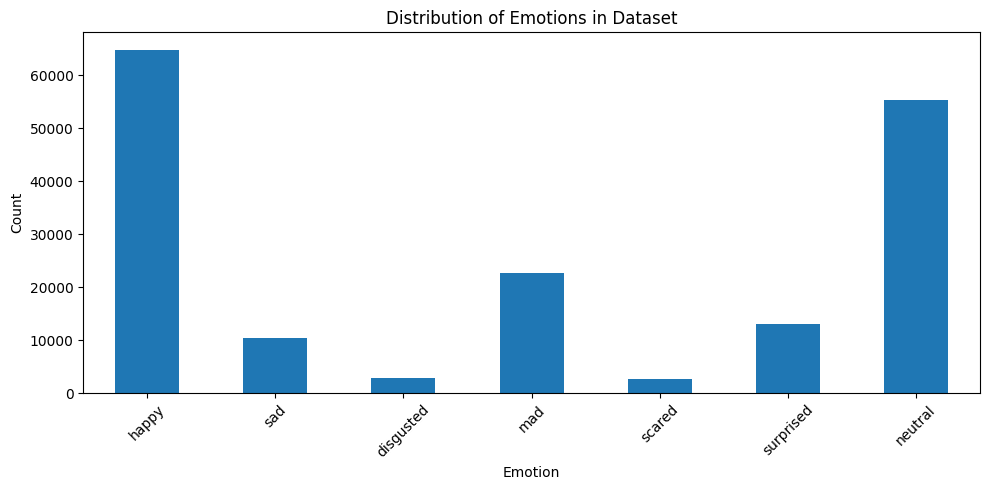

In [22]:
# Distribution of emotions in the dataset
plt.figure(figsize=(10, 5))
df[emotion_cols].sum().plot(kind='bar')
plt.title('Distribution of Emotions in Dataset')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
# --- 3. Prepare the Text Data ---
texts = df['text'].astype(str).tolist()  # ensure all texts are strings

# Set parameters for tokenization and padding
max_num_words = 10000  # maximum number of words to consider in the vocabulary
max_sequence_length = 100  # adjust based on your data (or use the maximum length in your dataset)
embedding_dim = 100  # size of the embedding vector

tokenizer = Tokenizer(num_words=max_num_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index
print("Found %s unique tokens." % len(word_index))

# Pad sequences so that each input has the same length
X = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')

Found 32495 unique tokens.


In [24]:
# --- 4. Split Data --- [Modified Cell 6]
# Split both text sequences and additional features
X_train, X_val, X_additional_train, X_additional_val, y_train, y_val = train_test_split(
    X,                          # text sequences
    numerical_features_scaled,   # additional features
    y_cat,                      # labels
    test_size=0.2,
    random_state=42
)

In [25]:
# --- 5. Build the LSTM Model --- [Modified Cell 7]
# Text input branch
text_input = Input(shape=(max_sequence_length,), name='text_input')
embedding = Embedding(input_dim=min(max_num_words, len(word_index) + 1),
                     output_dim=embedding_dim,
                     input_length=max_sequence_length)(text_input)
lstm = LSTM(128, dropout=0.2, recurrent_dropout=0.1)(embedding)

# Additional features branch
additional_input = Input(shape=(len(numerical_features),), name='additional_features')
additional_dense = Dense(64, activation='relu')(additional_input)
additional_dropout = Dropout(0.2)(additional_dense)

# Combine branches
combined = Concatenate()([lstm, additional_dropout])
dense1 = Dense(128, activation='relu')(combined)
dropout1 = Dropout(0.3)(dense1)
dense2 = Dense(64, activation='relu')(dropout1)
output = Dense(len(emotion_cols), activation='softmax')(dense2)

# Create and compile model
model = Model(inputs=[text_input, additional_input], outputs=output)
model.compile(loss='categorical_crossentropy', 
             optimizer='adam', 
             metrics=['accuracy'])

# Display model summary
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 text_input (InputLayer)        [(None, 100)]        0           []                               
                                                                                                  
 additional_features (InputLaye  [(None, 6)]         0           []                               
 r)                                                                                               
                                                                                                  
 embedding (Embedding)          (None, 100, 100)     1000000     ['text_input[0][0]']             
                                                                                                  
 dense (Dense)                  (None, 64)           448         ['additional_features[0][0]']

In [26]:
# --- 6. Train the Model ---
epochs = 10
batch_size = 32

history = model.fit(
    [X_train, X_additional_train],  # Multiple inputs
    y_train,
    validation_data=([X_val, X_additional_val], y_val),
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/10
4296/4296 [==============================] - 440s 102ms/step - loss: 1.3690 - accuracy: 0.4737 - val_loss: 1.3555 - val_accuracy: 0.4752
Epoch 2/10
4296/4296 [==============================] - 475s 111ms/step - loss: 1.3574 - accuracy: 0.4789 - val_loss: 1.3562 - val_accuracy: 0.4763
Epoch 3/10
4296/4296 [==============================] - 471s 110ms/step - loss: 1.3552 - accuracy: 0.4793 - val_loss: 1.3524 - val_accuracy: 0.4771
Epoch 4/10
4296/4296 [==============================] - 473s 110ms/step - loss: 1.3535 - accuracy: 0.4792 - val_loss: 1.3506 - val_accuracy: 0.4777
Epoch 5/10
4296/4296 [==============================] - 464s 108ms/step - loss: 1.3517 - accuracy: 0.4788 - val_loss: 1.3525 - val_accuracy: 0.4773
Epoch 6/10
4296/4296 [==============================] - 471s 110ms/step - loss: 1.3514 - accuracy: 0.4800 - val_loss: 1.3530 - val_accuracy: 0.4771
Epoch 7/10
4296/4296 [==============================] - 459s 107ms/step - loss: 1.3504 - accuracy: 0.4800 - val_

In [27]:
# --- 7. Save the Model (optional) ---
model.save("lstm_model_3.h5")

1074/1074 [==============================] - 24s 22ms/step


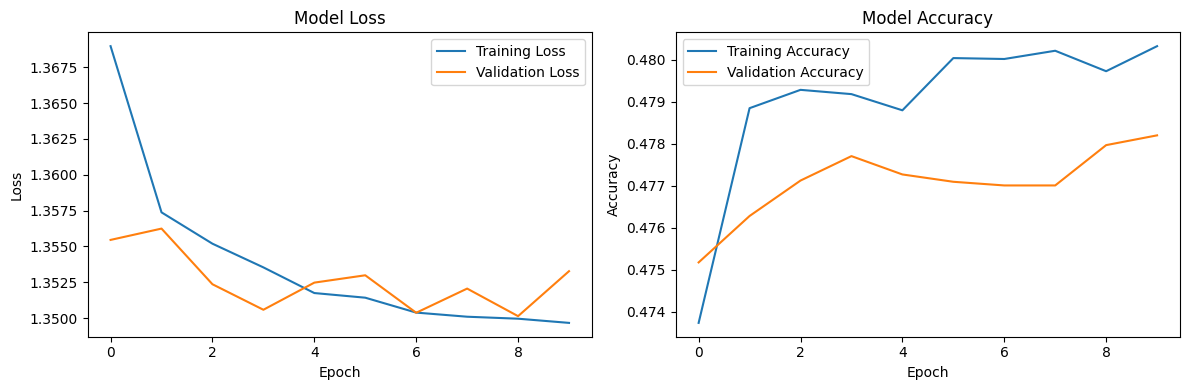


Classification Report:
              precision    recall  f1-score   support

       happy       0.60      0.69      0.64     13002
         sad       0.35      0.00      0.01      2140
   disgusted       0.25      0.00      0.00       584
         mad       0.31      0.15      0.20      4513
      scared       0.00      0.00      0.00       522
   surprised       0.00      0.00      0.00      2618
     neutral       0.40      0.62      0.48     10985

    accuracy                           0.48     34364
   macro avg       0.27      0.21      0.19     34364
weighted avg       0.42      0.48      0.42     34364



c:\Users\ronle\anaconda3\envs\y2c\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ronle\anaconda3\envs\y2c\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ronle\anaconda3\envs\y2c\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


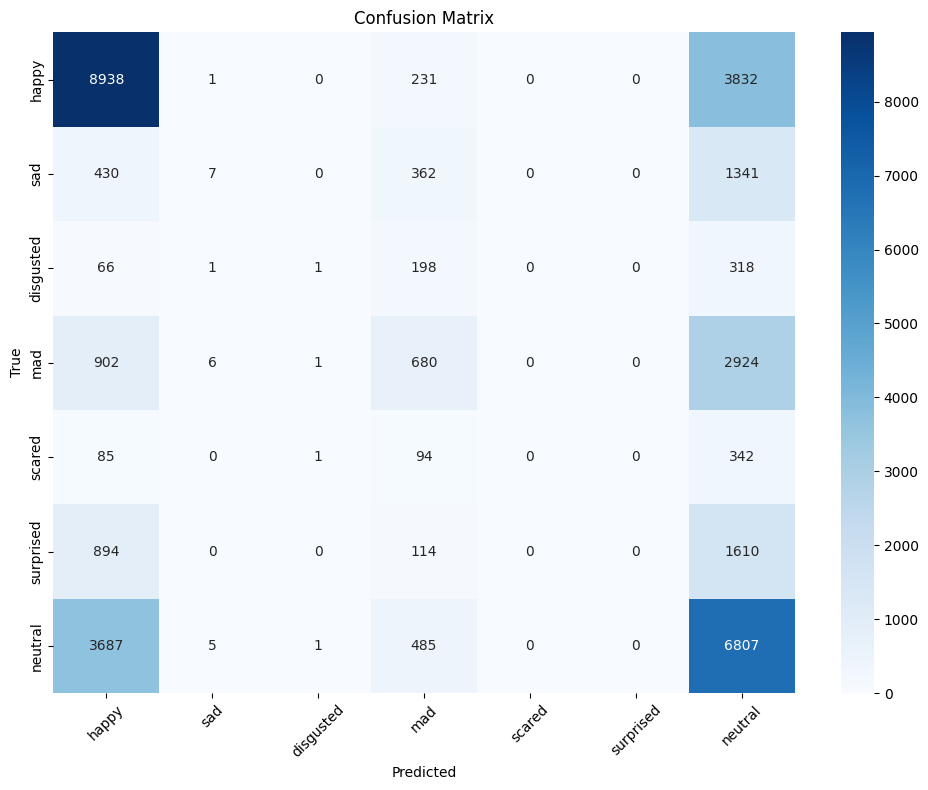

In [28]:
# --- 8. Model Evaluation and Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions using both inputs
y_pred = model.predict([X_val, X_additional_val])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

# Plot training history
plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, 
                          target_names=emotion_cols))

# Create confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_cols,
            yticklabels=emotion_cols)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
# [Cell 10] - Evaluate Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Get predictions
y_pred = model.predict([X_val, X_additional_val])

# Convert predictions to class indices
y_true_classes = np.argmax(y_val, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Calculate overall metrics (using weighted average)
accuracy = accuracy_score(y_true_classes, y_pred_classes)
precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')

# Print overall metrics
print("\nOverall Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

1074/1074 [==============================] - 19s 18ms/step

Overall Metrics:
Accuracy: 0.4782
Precision: 0.4194
Recall: 0.4782
F1 Score: 0.4233


c:\Users\ronle\anaconda3\envs\y2c\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
